In [1]:
## Trend Following Systematic Strategy


#import yfinance as yf
import numpy as np
import datetime
import pandas as pd

from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail
from saber import metaLib as mtlib
from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie

import matplotlib.pyplot as plt 


mtw = mtlib.meta5_wrapper()

In [2]:
import mt5plalib as pla

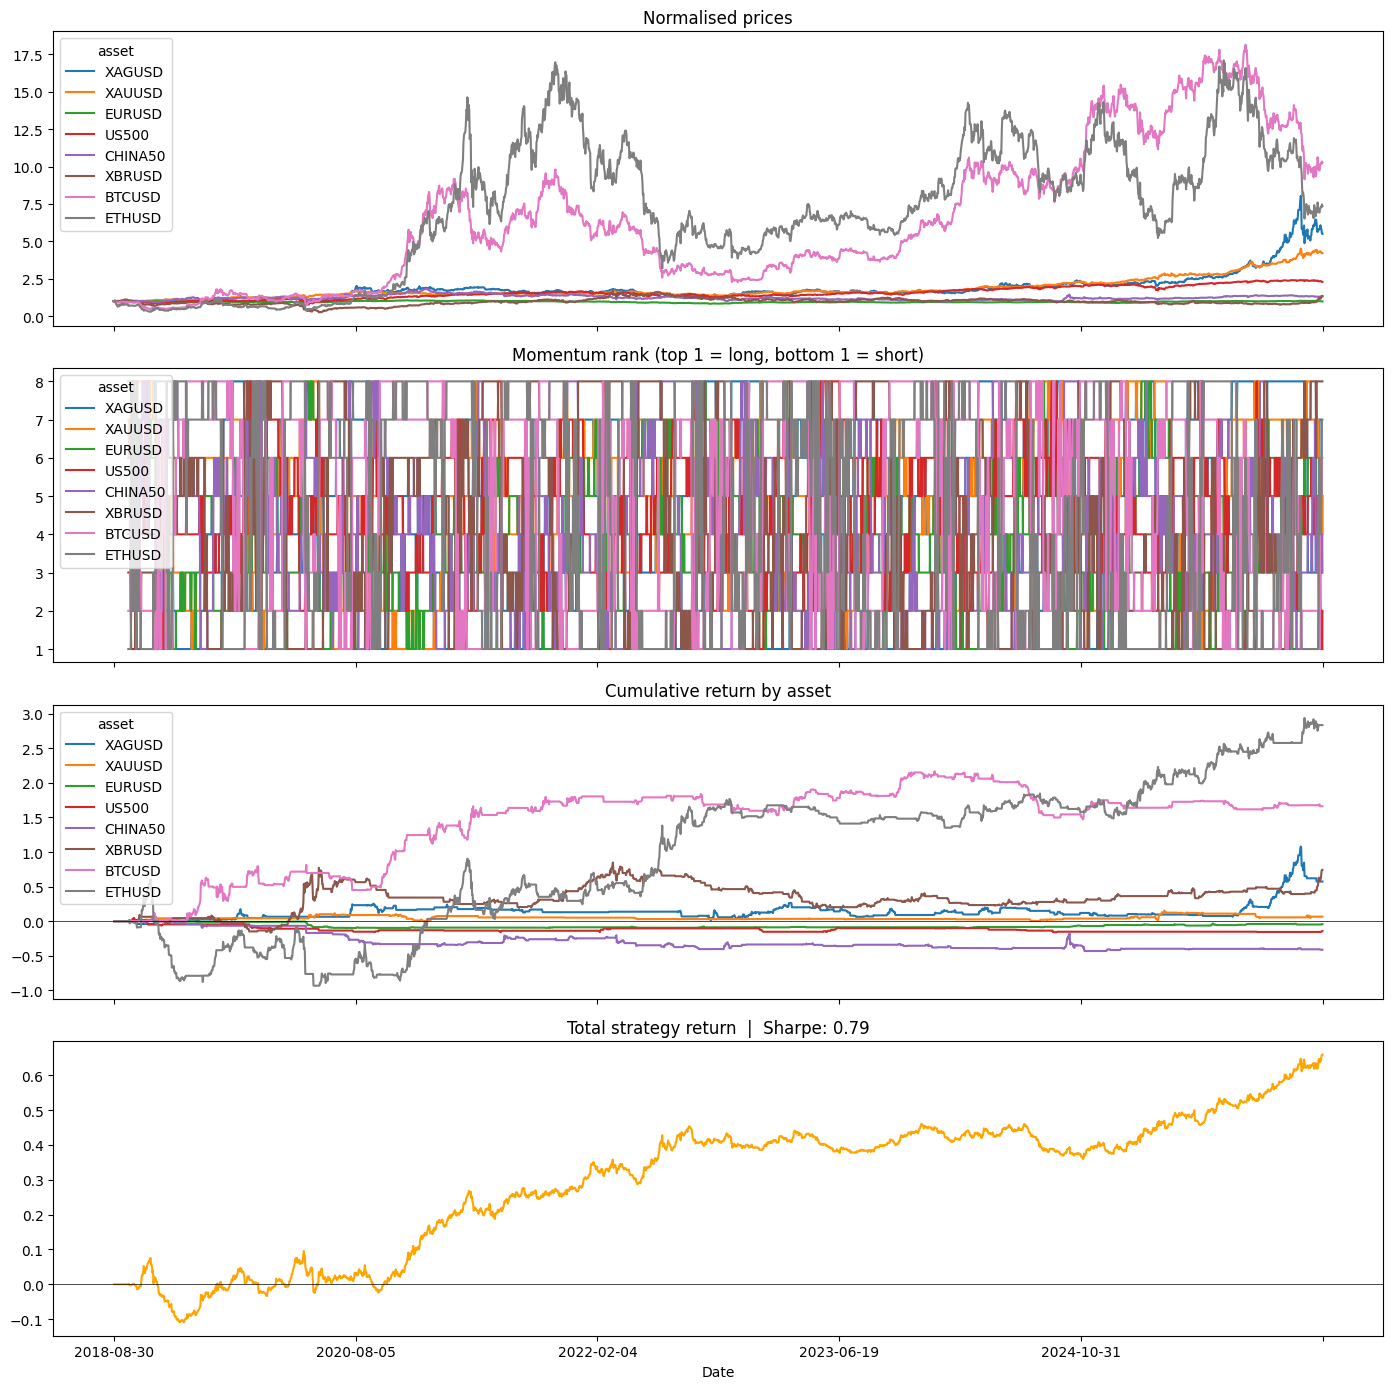

Ann. Return:  6.6%
Ann. Vol:     8.4%
Sharpe:       0.79

Latest ranks:
asset
XBRUSD     8.0
ETHUSD     7.0
BTCUSD     6.0
XAGUSD     5.0
XAUUSD     4.0
CHINA50    3.0
US500      2.0
EURUSD     1.0

Current signal:
asset
EURUSD   -1
XBRUSD    1


In [8]:
df = mtd.data(mtw).get_close_data()
df = df[['BTCUSD',"ETHUSD","XAGUSD","XAUUSD","EURUSD","US500"]]


def cross_sectional_momentum(df, lookback=20, long_n=2, short_n=2):
    ret     = df.pct_change()
    mom     = (ret.rolling(lookback).sum())#/(abs(ret).rolling(int(lookback/2)).sum())
    rank    = mom.rank(axis=1, ascending=True)
    n       = df.shape[1]

    signal = pd.DataFrame(0, index=df.index, columns=df.columns)
    signal[rank >= (n - long_n  + 1)] =  1
    signal[rank <= short_n           ] = -1

    asset_ret = signal.shift(1) * ret
    asset_cum = asset_ret.cumsum()
    strat_ret = asset_ret.mean(axis=1)
    sharpe    = strat_ret.mean() / strat_ret.std() * np.sqrt(252)

    # ── Plot ──
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

    df.div(df.iloc[0]).plot(ax=axes[0])
    axes[0].set_title('Normalised prices')

    rank.plot(ax=axes[1])
    axes[1].set_title(f'Momentum rank (top {long_n} = long, bottom {short_n} = short)')

    asset_cum.plot(ax=axes[2])
    axes[2].axhline(0, color='k', lw=0.5)
    axes[2].set_title('Cumulative return by asset')

    strat_ret.cumsum().plot(ax=axes[3], color='orange')
    axes[3].axhline(0, color='k', lw=0.5)
    axes[3].set_title(f'Total strategy return  |  Sharpe: {sharpe:.2f}')

    plt.tight_layout()
    plt.show()

    print(f"Ann. Return:  {strat_ret.mean()*252*100:.1f}%")
    print(f"Ann. Vol:     {strat_ret.std()*np.sqrt(252)*100:.1f}%")
    print(f"Sharpe:       {sharpe:.2f}")
    print(f"\nLatest ranks:\n{rank.iloc[-1].sort_values(ascending=False).to_string()}")
    print(f"\nCurrent signal:\n{signal.iloc[-1][signal.iloc[-1]!=0].to_string()}")

    return signal, rank, strat_ret


# ── Run ──
df = mtd.data(mtw).get_close_data()
df = df[['XAGUSD', 'XAUUSD', 'EURUSD', 'US500', 'CHINA50', 'XBRUSD', 'BTCUSD', 'ETHUSD']].ffill().dropna()

signal, rank, strat_ret = cross_sectional_momentum(df, lookback=30, long_n=1, short_n=1)

In [9]:
def get_directional_indicator(df,wdw = 10):
    px_chg = df['close'].pct_change()
    di = (px_chg.rolling(wdw,min_periods=2).mean())/(abs(px_chg).rolling(wdw,min_periods=2).mean())
    return di

def ma_crossover(price, fast=50, slow=200):
    """Returns +1 (long), -1 (short) signal based on MA crossover."""
    return np.sign(price.rolling(fast).mean() - price.rolling(slow).mean())




In [ ]:
def cross_sectional_momentum(df, lookback=20, long_n=2, short_n=2):
    ret     = df.pct_change()
    mom     = (ret.rolling(lookback).sum())#/(abs(ret).rolling(int(lookback/2)).sum())
    rank    = mom.rank(axis=1, ascending=True)
    n       = df.shape[1]

    signal = pd.DataFrame(0, index=df.index, columns=df.columns)
    signal[rank >= (n - long_n  + 1)] =  1
    signal[rank <= short_n           ] = -1

    asset_ret = signal.shift(1) * ret
    asset_cum = asset_ret.cumsum()
    strat_ret = asset_ret.mean(axis=1)
    sharpe    = strat_ret.mean() / strat_ret.std() * np.sqrt(252)

    # ── Plot ──
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

    df.div(df.iloc[0]).plot(ax=axes[0])
    axes[0].set_title('Normalised prices')

    rank.plot(ax=axes[1])
    axes[1].set_title(f'Momentum rank (top {long_n} = long, bottom {short_n} = short)')

    asset_cum.plot(ax=axes[2])
    axes[2].axhline(0, color='k', lw=0.5)
    axes[2].set_title('Cumulative return by asset')

    strat_ret.cumsum().plot(ax=axes[3], color='orange')
    axes[3].axhline(0, color='k', lw=0.5)
    axes[3].set_title(f'Total strategy return  |  Sharpe: {sharpe:.2f}')

    plt.tight_layout()
    plt.show()

    print(f"Ann. Return:  {strat_ret.mean()*252*100:.1f}%")
    print(f"Ann. Vol:     {strat_ret.std()*np.sqrt(252)*100:.1f}%")
    print(f"Sharpe:       {sharpe:.2f}")
    print(f"\nLatest ranks:\n{rank.iloc[-1].sort_values(ascending=False).to_string()}")
    print(f"\nCurrent signal:\n{signal.iloc[-1][signal.iloc[-1]!=0].to_string()}")

    return signal, rank, strat_ret


# ── Run ──
df = mtd.data(mtw).get_close_data()
df = df[['XAGUSD', 'XAUUSD', 'EURUSD', 'US500', 'CHINA50', 'XBRUSD', 'BTCUSD', 'ETHUSD']].ffill().dropna()

signal, rank, strat_ret = cross_sectional_momentum(df, lookback=30, long_n=1, short_n=1)

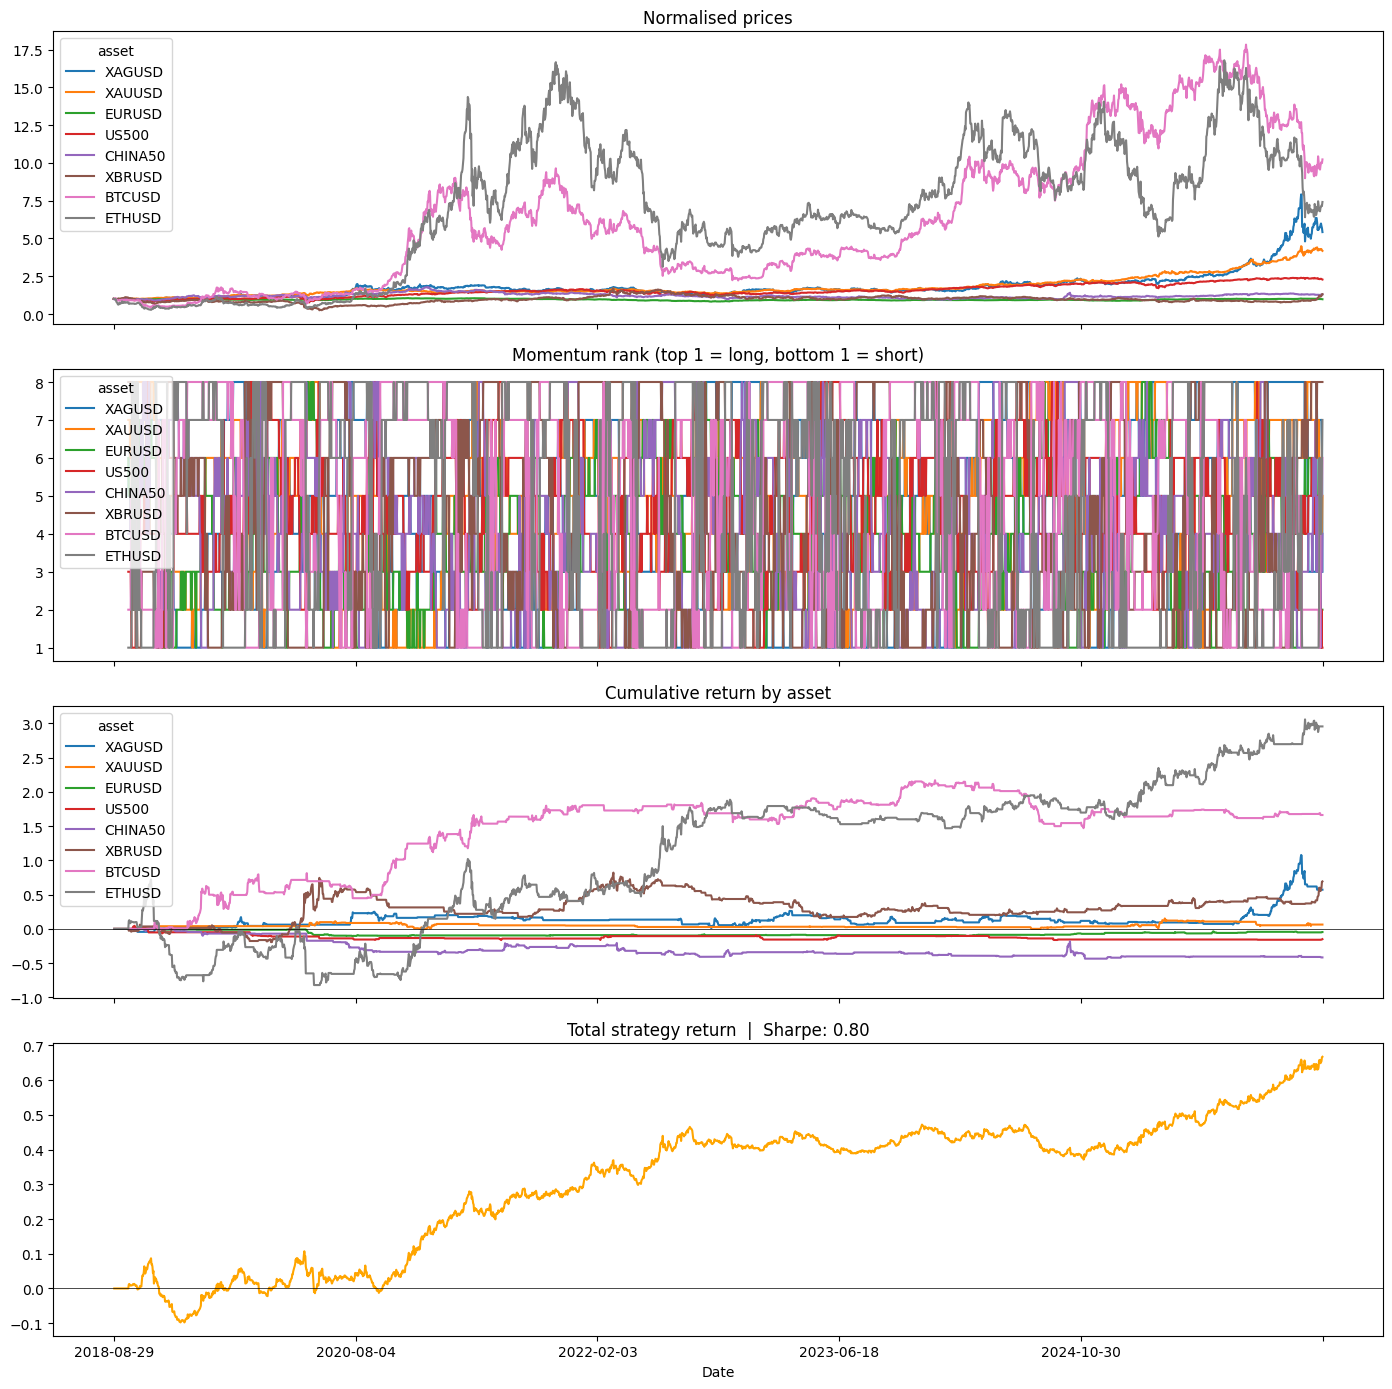

Ann. Return:  6.7%
Ann. Vol:     8.4%
Sharpe:       0.80

Latest ranks:
asset
XBRUSD     8.0
ETHUSD     7.0
BTCUSD     6.0
XAUUSD     5.0
CHINA50    4.0
XAGUSD     3.0
EURUSD     2.0
US500      1.0

Current signal:
asset
US500    -1
XBRUSD    1


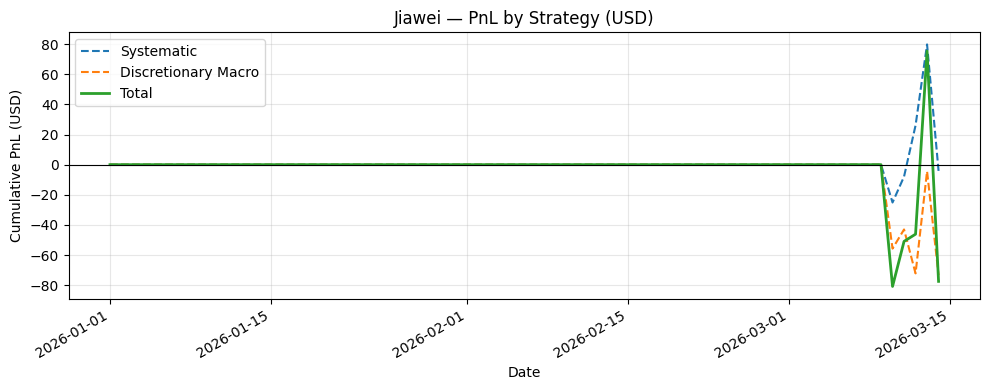


Jiawei | Invested: $2,245.00
  Systematic:          $-4.13
  Discretionary Macro: $-73.32
  Total PnL:           $-77.45  (-3.45%)


In [16]:
def get_investor_pnl(investors_df, pnl_df_sys, pnl_df_dm):
    """
    Returns dict of {investor_name: pd.DataFrame} with columns:
        Systematic, Discretionary Macro, Total
    """
    sys_daily = pnl_df_sys['TOTAL'].copy()
    sys_daily.index = pd.to_datetime(sys_daily.index)
    sys_daily = sys_daily.sort_index().diff().fillna(0)

    dm_daily = pnl_df_dm['TOTAL'].copy()
    dm_daily.index = pd.to_datetime(dm_daily.index)
    dm_daily = dm_daily.sort_index().diff().fillna(0)

    all_dates = sys_daily.index.union(dm_daily.index)
    sys_daily = sys_daily.reindex(all_dates, fill_value=0)
    dm_daily  = dm_daily.reindex(all_dates, fill_value=0)

    results = {}

    for name, records in investors_df.groupby('Name'):
        records = records.sort_values('Date').reset_index(drop=True)

        pct_sys_ts = pd.Series(0.0, index=all_dates)
        pct_dm_ts  = pd.Series(0.0, index=all_dates)

        for i, row in records.iterrows():
            period_start = pd.Timestamp(row['Date'])
            period_end   = pd.Timestamp(records.iloc[i + 1]['Date']) - pd.Timedelta(days=1) \
                           if i < len(records) - 1 else all_dates[-1]
            mask = (all_dates >= period_start) & (all_dates <= period_end)
            pct_sys_ts[mask] = row['Percentage Systematic']
            pct_dm_ts[mask]  = row['Percentage Discretionary']

        sys_pnl = (sys_daily * pct_sys_ts).cumsum()
        dm_pnl  = (dm_daily  * pct_dm_ts).cumsum()

        df = pd.DataFrame({
            'Systematic':          sys_pnl,
            'Discretionary Macro': dm_pnl,
            'Total':               sys_pnl + dm_pnl
        })
        results[name] = df

    return results


# ── Plot ──────────────────────────────────────────────────────────────────────
investors_df = pd.read_excel(INVESTORS_FILE)
investor_pnl = get_investor_pnl(investors_df, pnl_df_sys, pnl_df_dm)

for name, df in investor_pnl.items():
    fig, ax = plt.subplots(figsize=(10, 4))
    df['Systematic'].plot(ax=ax, label='Systematic', linestyle='--')
    df['Discretionary Macro'].plot(ax=ax, label='Discretionary Macro', linestyle='--')
    df['Total'].plot(ax=ax, label='Total', linewidth=2)
    ax.set_title(f"{name} — PnL by Strategy (USD)")
    ax.set_ylabel("Cumulative PnL (USD)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
for name, df in investor_pnl.items():
    latest = df.iloc[-1]
    invested = investors_df[investors_df['Name'] == name]['Amount Invested (USD)'].sum()
    print(f"\n{name} | Invested: ${invested:,.2f}")
    print(f"  Systematic:          ${latest['Systematic']:,.2f}")
    print(f"  Discretionary Macro: ${latest['Discretionary Macro']:,.2f}")
    print(f"  Total PnL:           ${latest['Total']:,.2f}  ({latest['Total']/invested*100:.2f}%)")


            Systematic  Discretionary Macro     Total
Date                                                 
2026-01-01      0.0000              0.00000   0.00000
2026-01-02      0.0000              0.00000   0.00000
2026-01-03      0.0000              0.00000   0.00000
2026-01-06      0.0000              0.00000   0.00000
2026-01-07      0.0000              0.00000   0.00000
2026-01-08      0.0000              0.00000   0.00000
2026-01-10      0.0000              0.00000   0.00000
2026-01-12      0.0000              0.00000   0.00000
2026-01-14      0.0000              0.00000   0.00000
2026-01-16      0.0000              0.00000   0.00000
2026-01-17      0.0000              0.00000   0.00000
2026-01-19      0.0000              0.00000   0.00000
2026-01-20      0.0000              0.00000   0.00000
2026-01-21      0.0000              0.00000   0.00000
2026-01-22      0.0000              0.00000   0.00000
2026-01-23      0.0000              0.00000   0.00000
2026-01-24      0.0000      

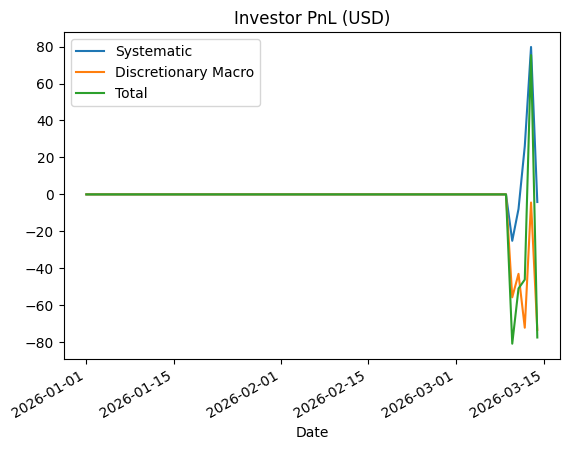

In [17]:
investors_df = pd.read_excel('investors.xlsx')

pnl_df_dm = plalb.build_pnl_from_files(r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro")

pnl_df_sys = plalb.build_pnl_from_files(r'C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\systematic')


investor_pnl = get_investor_pnl(investors_df, pnl_df_sys, pnl_df_dm)

# View Jiawei's PnL
print(investor_pnl['Jiawei'])

# Plot all investors
for name, pnl in investor_pnl.items():
    pnl.plot(label=name)
plt.legend()
plt.title("Investor PnL (USD)")
plt.show()